In [1]:
import tensorflow as tf
import kagglehub
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, regularizers, callbacks
from google.colab import drive
from tensorflow.keras.preprocessing import image

In [2]:
drive.mount('/content/drive')

BACKUP_DIR = '/content/drive/MyDrive/Flower17_Project/Backup'
BEST_MODEL_PATH = '/content/drive/MyDrive/Flower17_Project/best_flower_cnn_model.keras'

os.makedirs(BACKUP_DIR, exist_ok=True)
print(BACKUP_DIR)

Mounted at /content/drive
/content/drive/MyDrive/Flower17_Project/Backup


In [3]:
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("aima138/17flowerclasses")
print(f"Dataset downloaded to: {dataset_path}")

print(f"Contents of {dataset_path}:")
print(os.listdir(dataset_path))

folder_name = os.listdir(dataset_path)[0]
print(f"Contents inside {folder_name}:")
print(os.listdir(os.path.join(dataset_path, folder_name)))

TRAIN_DIR = os.path.join(dataset_path, "17flowerclasses", "train")
TEST_DIR = os.path.join(dataset_path, "17flowerclasses", "test")

100%|██████████| 57.8M/57.8M [00:00<00:00, 140MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/aima138/17flowerclasses/versions/1
Contents of /root/.cache/kagglehub/datasets/aima138/17flowerclasses/versions/1:
['17flowerclasses']
Contents inside 17flowerclasses:
['test', 'train']


In [4]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("\nLoading Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data:")
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Test Data:")
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Loading Training Data:
Found 1190 files belonging to 17 classes.
Using 952 files for training.

Loading Validation Data:
Found 1190 files belonging to 17 classes.
Using 238 files for validation.

Loading Test Data:
Found 170 files belonging to 17 classes.
Classes: ['Bluebell', 'ButterCup', 'ColtsFoot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'LilyValley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'WindFlower', 'tulip']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.3),
  layers.RandomZoom(0.2),
  layers.RandomTranslation(0.2, 0.2),
  layers.RandomContrast(0.2)
], name="data_augmentation")

In [7]:

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=17):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        layers.Rescaling(1./255),

        # Block 1
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 4
        layers.Conv2D(512, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),


        layers.GlobalAveragePooling2D(),


        layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),


        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_custom_cnn(input_shape=IMG_SIZE + (3,), num_classes=17)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,828,241 (6.97 MB)

 Trainable params: 1,825,297 (6.96 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [8]:
callbacks_list = [

    tf.keras.callbacks.BackupAndRestore(
        backup_dir=BACKUP_DIR
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

In [9]:

EPOCHS = 150
print("\nStarting (or Resuming) Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)


Starting (or Resuming) Training...
Epoch 1/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.1975 - loss: 2.9428
Epoch 1: val_accuracy improved from None to 0.17647, saving model to /content/drive/MyDrive/Flower17_Project/best_flower_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Flower17_Project/best_flower_cnn_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 31s 518ms/step - accuracy: 0.2595 - loss: 2.5476 - val_accuracy: 0.1765 - val_loss: 2.7682 - learning_rate: 0.0010
Epoch 2/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.3642 - loss: 2.0485
Epoch 2: val_accuracy did not improve from 0.17647
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 395ms/step - accuracy: 0.3529 - loss: 2.0595 - val_accuracy: 0.0756 - val_loss: 3.1767 - learning_rate: 0.0010
Epoch 3/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.4135 - loss: 1.8914
Epoch 3: val_accuracy did not improve from 0.17647
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - accuracy: 0.4181 - loss: 1.8730 -

In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5941 - loss: 1.5626

Test Accuracy: 59.41%
Test Loss: 1.5626


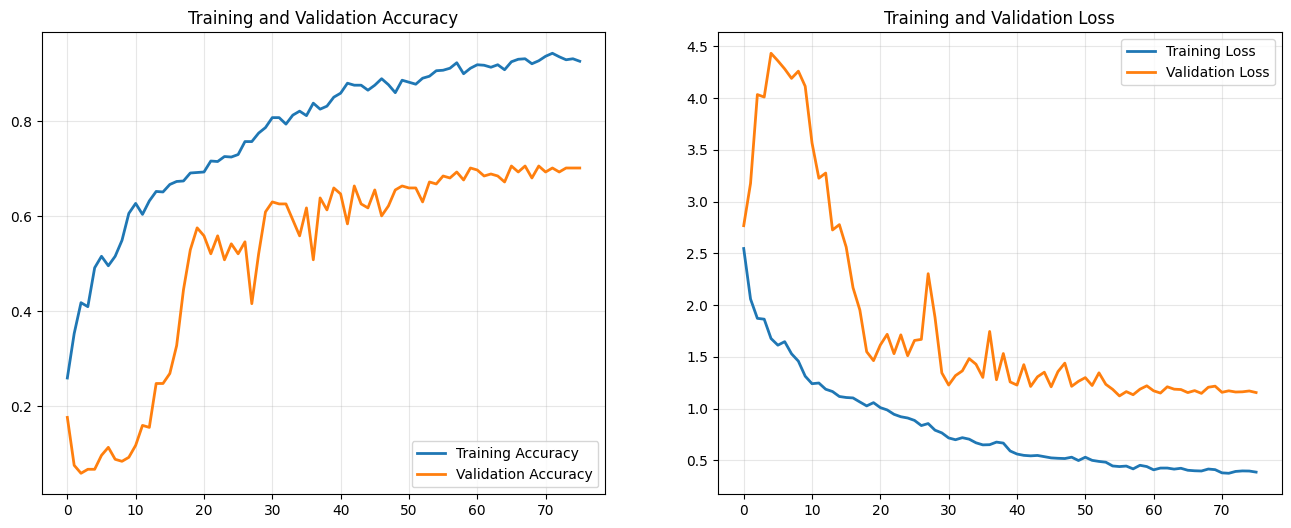

In [11]:

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.grid(True, alpha=0.3)

    plt.show()

plot_history(history)

In [12]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

In [13]:
print("CLASSIFICATION REPORT: ")
print(classification_report(y_true, y_pred, target_names=class_names))

CLASSIFICATION REPORT: 
              precision    recall  f1-score   support

    Bluebell       0.83      0.50      0.62        10
   ButterCup       0.64      0.70      0.67        10
   ColtsFoot       0.47      0.70      0.56        10
     Cowslip       0.35      0.60      0.44        10
      Crocus       0.60      0.60      0.60        10
    Daffodil       0.40      0.20      0.27        10
       Daisy       1.00      0.40      0.57        10
   Dandelion       0.86      0.60      0.71        10
  Fritillary       0.62      0.80      0.70        10
        Iris       0.45      0.50      0.48        10
  LilyValley       0.67      0.80      0.73        10
       Pansy       0.67      0.40      0.50        10
    Snowdrop       0.40      0.20      0.27        10
   Sunflower       0.86      0.60      0.71        10
   Tigerlily       0.90      0.90      0.90        10
  WindFlower       0.62      0.80      0.70        10
       tulip       0.44      0.80      0.57        10

  

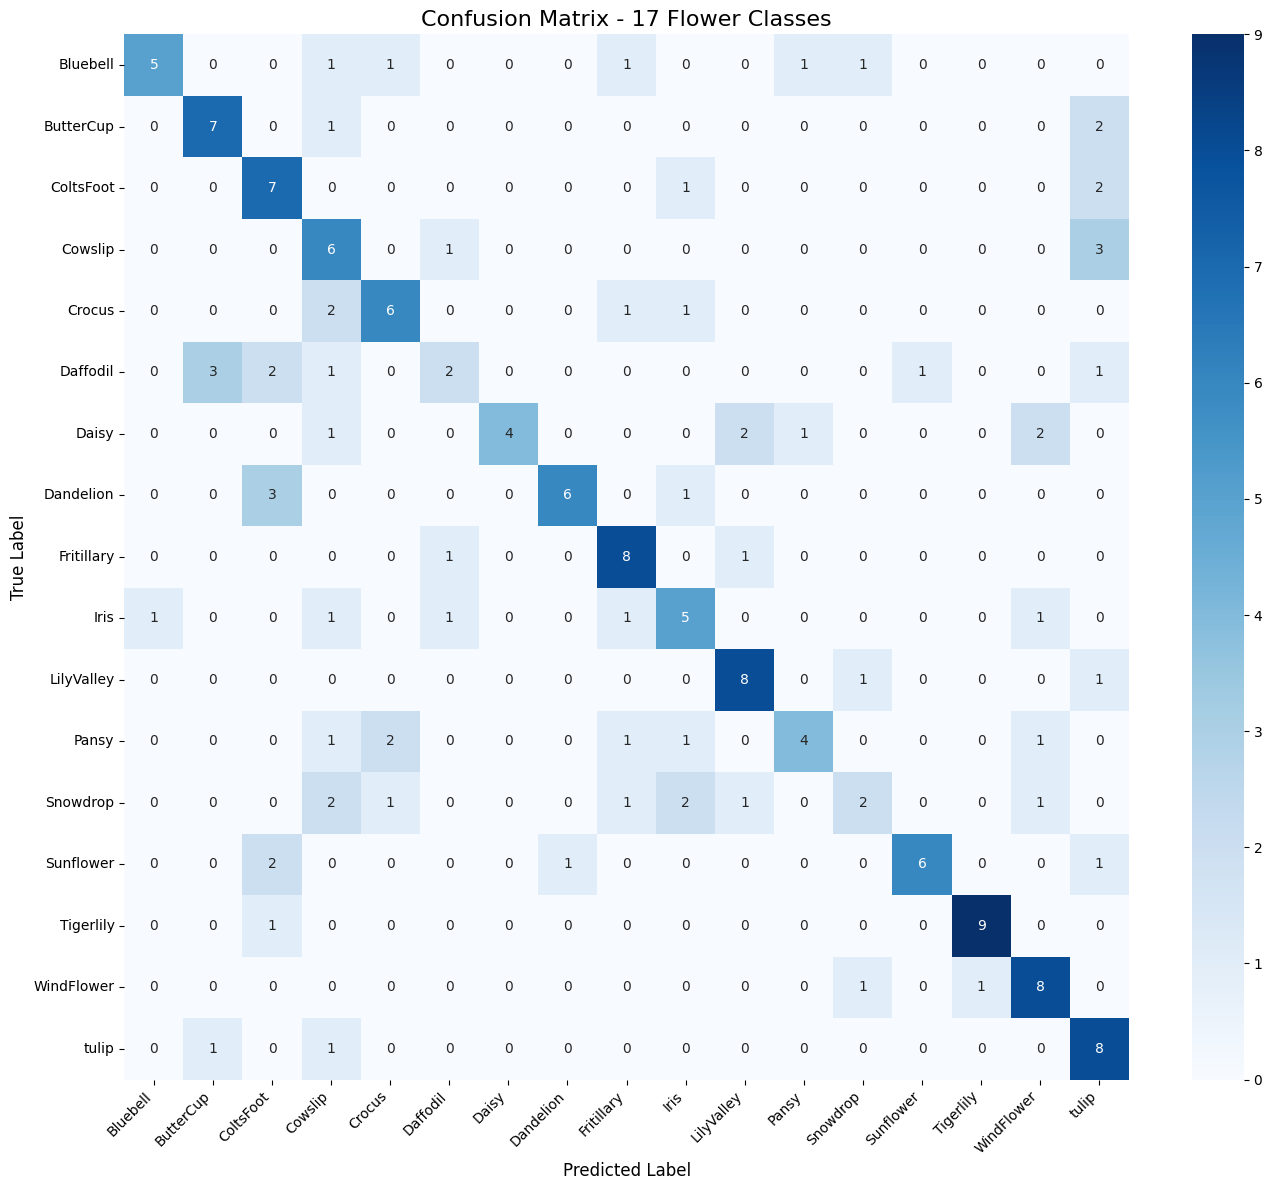

In [14]:

plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - 17 Flower Classes', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
test_images = ['01.jpg', '02.jpg', '03.jpg', '04.jpg']

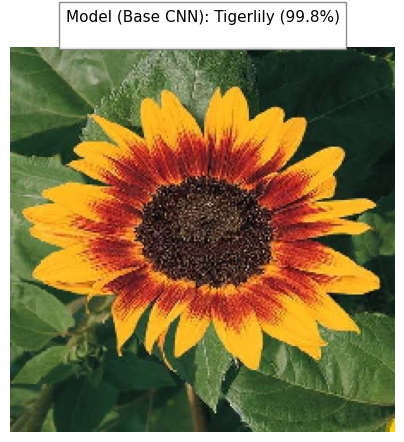

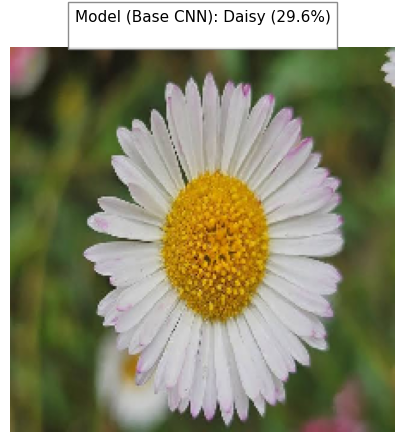

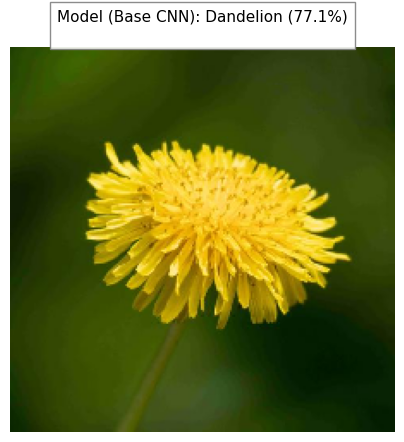

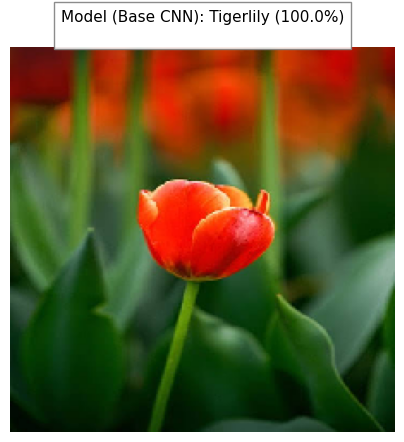

In [17]:
for img_name in test_images:

    img = image.load_img(img_name, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    try:
        pred_base = model.predict(img_array, verbose=0)
        class_base = class_names[np.argmax(pred_base[0])]
        conf_base = np.max(pred_base[0]) * 100
    except NameError:
        class_base, conf_base = "model error", 0

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")

    title_text = (
        f"Model (Base CNN): {class_base} ({conf_base:.1f}%)\n"
    )
    plt.title(title_text, loc='center', fontsize=11, color='black',
              bbox=dict(facecolor='white', alpha=0.9, pad=5, edgecolor='gray'))
    plt.show()